In [20]:
import numpy as np
import pandas as pd
import sympy as sm
from scipy.stats import gamma
from tqdm.notebook import tqdm
import igraph as ig

import os
import sys

# Standard interactive replacement for the 'parent directory' hack
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from utils import remove_cycles, mat_from_np, move_scattered_identity
from PPRCalculator import PPRCalculator

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Models

### ToyModel#1

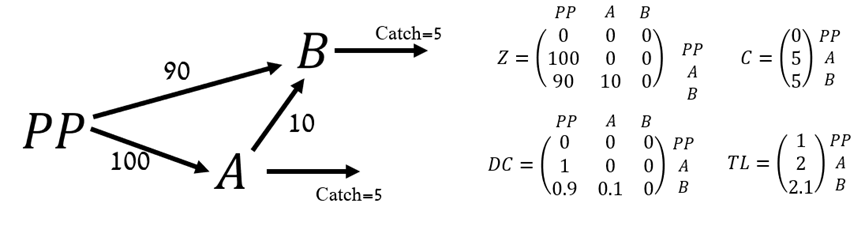

In [21]:
Z = pd.DataFrame({
    0: [0, 0, 0, 0],
    1: [0, 0, 0, 0],
    2: [100, 0, 0, 0],
    3: [90, 0, 10, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A', 
    3: 'B'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A', 'B']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular', 'Regular']
groups_df['q'] = [190, 0, 100, 100]
groups_df['p'] = [190, 0, 15, 5]
groups_df['catch'] = [0, 0, 5, 5]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = 0
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = 0
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

In [14]:
self.is_model_balanced()

(True,
 3      5
 2     15
 1      0
 0    190
 dtype: int64,
 3    100
 2    100
 1      0
 0    190
 dtype: int64)

### SimpleCycle1

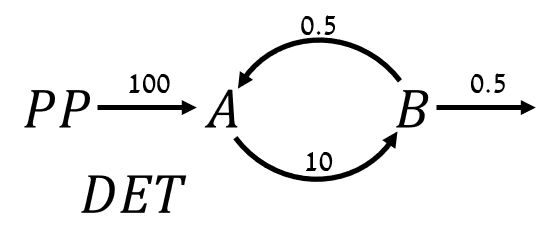

In [36]:
Z = pd.DataFrame({
    0: [0, 0, 0, 0],
    1: [0, 0, 0, 0],
    2: [100, 0, 0, 0.5],
    3: [0, 0, 10, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A', 
    3: 'B'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A', 'B']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular', 'Regular']
groups_df['q'] = [100, 0, 100.5, 10]
groups_df['p'] = [100, 0, 10, 1]
groups_df['catch'] = [0, 0, 0, 0.5]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = 0
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = 0
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series'), underdetermined=False
)

In [3]:
self.is_model_balanced()

(True,
 3      1.0
 2     10.0
 1      0.0
 0    100.0
 dtype: float64,
 3     10.0
 2    100.5
 1      0.0
 0    100.0
 dtype: float64)

### ModelWithDET

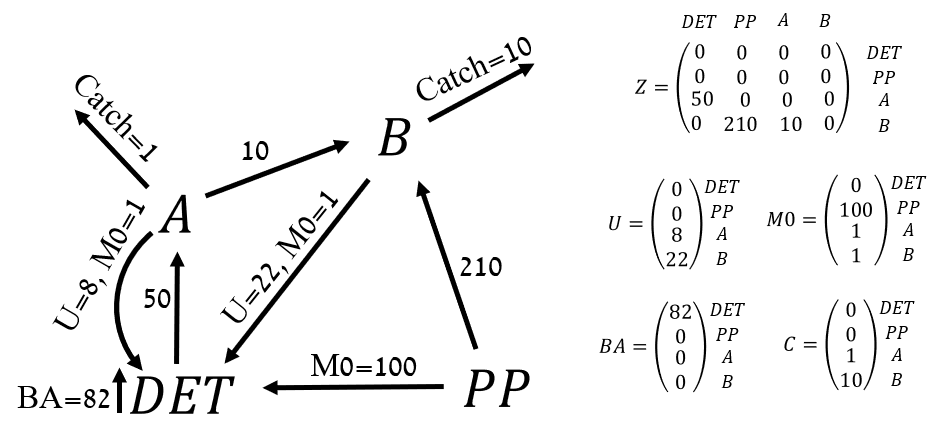

In [39]:
Z = pd.DataFrame({
    0: [0, 0, 0, 0],
    1: [0, 0, 0, 0],
    2: [50, 0, 0, 0],
    3: [0, 210, 10, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'DET',
    1: 'PP',
    2: 'A', 
    3: 'B'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['DET', 'PP', 'A', 'B']
groups_df['trophic_info'] = ['DET', 'PP', 'Regular', 'Regular']
groups_df['q'] = [132, 310, 50, 220]
groups_df['p'] = [132, 310, 12, 11]
groups_df['catch'] = [0, 0, 1, 10]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = [82, 0, 0, 0]
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = [0, 100, 1, 1]
groups_df['egestion'] = [0, 0, 8, 22]
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

# groups_df['ee'] = np.nan
# groups_df['M0'] = np.nan

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series'), underdetermined=False
)

In [3]:
self.is_model_balanced()

(True,
 3     11.0
 2     12.0
 1    310.0
 0    132.0
 dtype: float64,
 3    220.0
 2     50.0
 1    310.0
 0    132.0
 dtype: float64)

## Calculations

In [19]:
# self.get_TL(break_cycles=True, DET_as_PP=True)
self.get_TL(break_cycles=False, DET_as_PP=True)
# remove_cycles(self.get_Z(DET_as_PP=True).copy(), new=False)
# self.get_Z(DET_as_PP=True)

3    2.045455
2    2.000000
1    1.000000
0    1.000000
dtype: float64

In [32]:
sppr = self.SPPR_1986()
sppr = PPRCalculator.rename_results(sppr, self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
# sppr.sum(axis=1)
sppr

catch    120.980395
dtype: float64
balanced: (False, np.int64(310), np.float64(1022.8342511475194))


,sppr
B,10.998218
A,10.998218
PP,10.998218
DET,10.998218


In [54]:
310-10*11.103363181676379 - 10 - 82

106.96636818323623

In [33]:
sppr = self.SPPR_1995(global_TE=0.1)
sppr = PPRCalculator.rename_results(sppr, self.seq2name)
print(self.get_PPR(sppr).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
# sppr.sum(axis=1)
sppr

catch    121.033632
dtype: float64
balanced: (False, np.int64(310), np.float64(203.03363181676377))


,sppr
B,11.103363
A,10.000000
PP,1.000000
DET,1.000000


In [34]:
sppr, A, L = self.SPPR_EwE(TE_option='TE', use_EE=True)
sppr, A = PPRCalculator.rename_results([sppr, A], self.seq2name)
print(self.get_PPR(sppr, only_inner=True).sum(axis=1))
print(self.get_PPR(sppr).rename(columns=self.seq2name))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
print(f'PPR/NPP: {self.get_PPR2NPP_ratio(sppr)}')
# sppr.sum(axis=1)
sppr

catch    236.398072
dtype: float64
               PP        DET
catch  190.909091  45.488981
balanced: (False, np.int64(310), np.float64(318.39807162534436))
PPR/NPP: 0.762574424597885


,PP,DET
B,19.090909,4.132231
A,0.000000,4.166667
PP,0.677419,0.000000
DET,0.000000,1.000000


In [35]:
sppr, A, L = self.SPPR_2015(only_pp_det=True)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr, only_inner=True).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
print(f'PPR/NPP: {self.get_PPR2NPP_ratio(sppr)}')
# sppr.sum(axis=1)
sppr

catch    247.878788
dtype: float64
balanced: (True, np.int64(310), np.float64(310.0))
PPR/NPP: 0.7996089931573801


,PP
B,24.443526
A,3.443526
PP,1.000000
DET,0.757576


In [16]:
sppr, A, L = self.SPPR_EwE_Ulanowicz(TE_option='TE', use_EE=True)
sppr, A = PPRCalculator.rename_results([sppr, A], self.seq2name)
print(self.get_PPR(sppr, only_inner=True).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
print(f'PPR/NPP: {self.get_PPR2NPP_ratio(sppr)}')
# sppr.sum(axis=1)
sppr

catch    50.0
dtype: float64
balanced: (False, np.int64(100), np.float64(50.0))
PPR/NPP: 0.5


,DET,PP
B,0.0,100.0
A,0.0,10.0
DET,NaN,NaN
PP,0.0,1.0


In [52]:
sppr, A, L = self.SPPR_new(TE=None, TE_option='TE', DET_TE_vals=1)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr, only_inner=True).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
print(f'PPR/NPP: {self.get_PPR2NPP_ratio(sppr)}')
# sppr.sum(axis=1)
sppr

catch    247.878788
dtype: float64
balanced: (True, np.int64(310), np.float64(310.0))
PPR/NPP: 0.7996089931573802


,PP,DET
B,21.0,3.443526
A,0.0,3.443526
PP,1.0,0.000000
DET,0.0,0.757576


In [8]:
only_pp_det=True

groups_data = self.get_groups_df()
production = self.p.copy()
PP_seq = list(self.get_Import_seq()) + list(self.get_PP_seq())
DET_seq = self.get_DET_seq()[0]  # assuming there is only one DET
Z = self.get_Z(DET_as_PP=False)

# combine part of DET that is PP into PP row:
Z_without_DET = Z.copy()
percent_of_det_that_is_PP = Z_without_DET.loc[DET_seq, PP_seq] / Z_without_DET.loc[DET_seq, :].sum()  # 98%
percent_of_det_that_is_PP = percent_of_det_that_is_PP.fillna(0)
if only_pp_det:  # this is what is implemented in the article
    for i in PP_seq:
        Z_without_DET.loc[:, i] += percent_of_det_that_is_PP[i] * Z_without_DET.loc[:, DET_seq]
else:
    Z_without_DET.loc[:, PP_seq] += Z_without_DET.loc[:, DET_seq]
Z_without_DET = Z_without_DET.drop(index=DET_seq, columns=DET_seq)

# production of living compartments:
new_index = Z_without_DET.index
P = production[new_index].copy()
ee = groups_data.loc[new_index, "ee"].fillna(1)
non_PP = groups_data['trophic_info'] == 'Regular'
P[non_PP] = P[non_PP].mul(ee[non_PP])   # P*EE = (export + predation + growth + net_migration), without M0
# EE = (export + predation + growth + net_migration) / (export + predation + growth + net_migration + M0)
P = P.sort_index(ascending=False)

# production-normalized transaction matrix:
A = (Z_without_DET.T.sort_index(ascending=False).sort_index(axis=1, ascending=False) / P).fillna(0)

# production requirement matrix:
seq_to_drop = P.index[P == 0]
A = A.drop(columns=seq_to_drop, index=seq_to_drop)
L = pd.DataFrame(np.linalg.inv((np.identity(A.shape[0]) - A)), index=A.index, columns=A.columns)
L[seq_to_drop] = 0
new_index = L.index.union(seq_to_drop)
L = L.reindex(new_index).fillna(0)
L.loc[seq_to_drop, seq_to_drop] = 1
SPPR = L.loc[PP_seq, :].T

# add back sppr_det that makes model balanced:
SPPR = SPPR.reindex(self.catch.index, fill_value=0)
for i in PP_seq:
    SPPR.loc[self.get_DET_seq(), i] = self.M0.loc[PP_seq][i] / (self.M0 + self.egestion).sum()

SPPR

C:\Users\idoca\AppData\Local\Temp\ipykernel_64496\2877317718.py:45: RuntimeWarning: invalid value encountered in scalar divide
  SPPR.loc[self.get_DET_seq(), i] = self.M0.loc[PP_seq][i] / (self.M0 + self.egestion).sum()


,0
3,200.0
2,20.0
1,NaN
0,1.0


In [35]:
A

,B,A,DET,PP
B,0.00,10.0,0.0,0.0
A,0.05,0.0,0.0,10.0
DET,0.00,0.0,1.0,0.0
PP,0.00,0.0,0.0,1.0
